# Numerical Simulation Laboratory - Notebook 2

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy.optimize import curve_fit

## Exercise 02.1

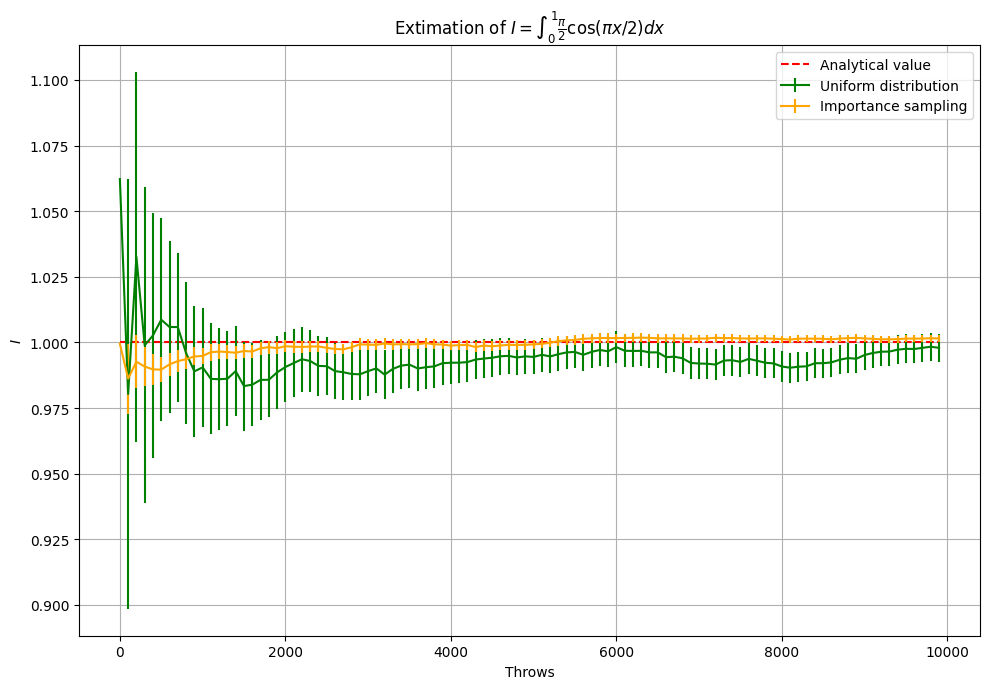

In [2]:
x_uniform, I_uniform, err_uniform = np.loadtxt("../02-Exercises/OUTPUT/uniform.out", unpack=True)
x_importance, I_importance, err_importance = np.loadtxt("../02-Exercises/OUTPUT/importance.out", unpack=True)

fig, ax = plt.subplots(figsize=(10,7))

ax.plot(x_uniform, [1.]*x_uniform.size, "r--", label="Analytical value")
ax.errorbar(x_uniform, I_uniform, yerr=err_uniform, color="g", label="Uniform distribution");
ax.errorbar(x_importance, I_importance, yerr=err_importance, color="orange", label="Importance sampling");

ax.set_title(r"Extimation of $I = \int_0^1 \frac{\pi}{2}\cos(\pi x/2) dx$")
ax.set_xlabel("Throws")
ax.set_ylabel("$I$")

fig.tight_layout()
ax.legend()
ax.grid();

To integrate with importance sampling I've used the first order Taylor expansion of $\cos\left(\frac{\pi}{2}x\right)$ in $x=1$:
$$ \cos\left(\frac{\pi}{2}x\right) = -\frac{\pi}{2}(x-1) \text{.}$$
This expansion can be used as the probability distribution for the importance sampling after normalization
$$\int_0^1\frac{\pi}{2}(1-x)dx=\frac{\pi}{4}\text{,}$$
$$p(x)=2(1-x)\text{,}$$
$$\int_0^1\cos\left(\frac{\pi}{2}x\right)dx=\int_0^1\frac{\pi\cos\left(\frac{\pi}{2}x\right)}{4(1-x)}2(1-x)dx\text{.}$$
The probability distribution $p(x)$ can be sampled from a uniform distribution by inverting the cumulative funtion
$$y=\int_0^x2(1-x^\prime)dx^\prime=2x-x^2\implies x=1-\sqrt{1-y}\text{,}$$
with $y\in\mathcal{U}[0,1]$.
The figure shows that the integral with importance sampling converges faster and has lower error than the one with uniform sampling: the final error with importance sampling is about $4$ times smaller than the one with uniform sampling. Both methods converge to the true value of $I$.

## Excercise 02.2

Reduced chi^2 of lattice fit: 0.273
Reduced chi^2 of continuum fit: 0.731


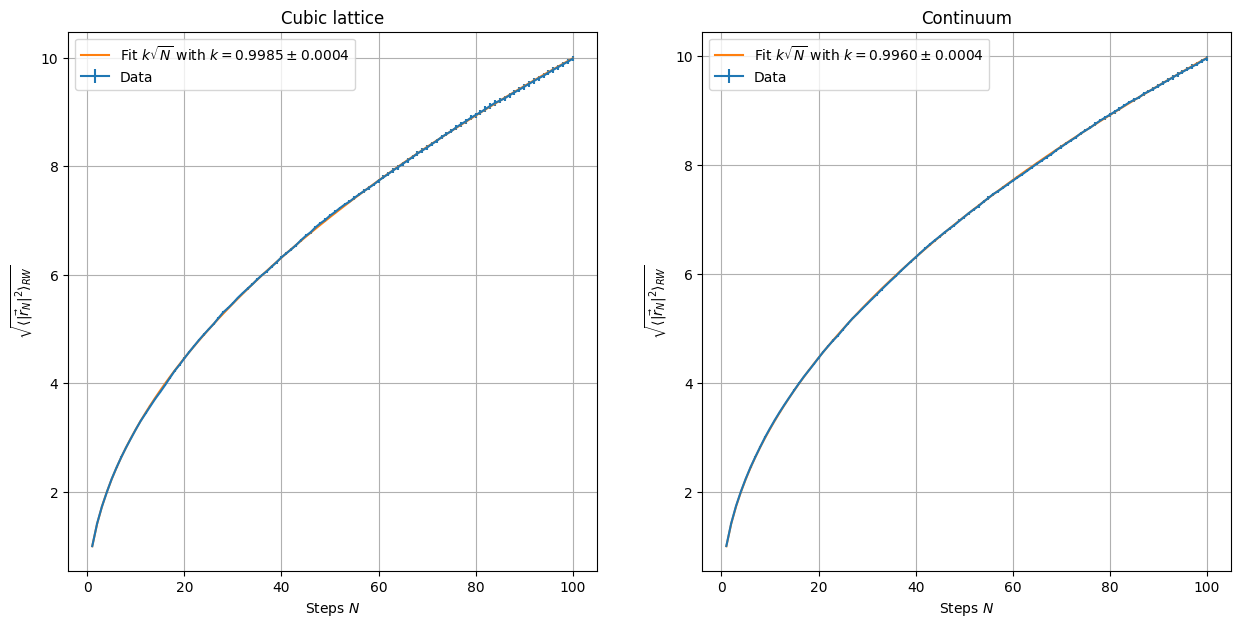

In [61]:
x_lattice, dist_lattice, err_lattice = np.loadtxt("../02-Exercises/OUTPUT/RW_lattice.out", unpack=True)
x_cont, dist_cont, err_cont = np.loadtxt("../02-Exercises/OUTPUT/RW_continuum.out", unpack=True)

lattice_opt, lattice_cov = curve_fit(lambda N, k : k*np.sqrt(N), x_lattice[1:], dist_lattice[1:], sigma=err_lattice[1:], absolute_sigma=True)
cont_opt, cont_cov = curve_fit(lambda N, k : k*np.sqrt(N), x_cont[1:], dist_cont[1:], sigma=err_cont[1:], absolute_sigma=True)
lattice_fit_err = np.sqrt(lattice_cov[0,0])
cont_fit_err = np.sqrt(cont_cov[0,0])

fig, axs = plt.subplots(1, 2, figsize=(15,7))

axs[0].errorbar(x_lattice, dist_lattice, yerr=err_lattice, label="Data");
axs[0].plot(x_lattice, lattice_opt[0]*np.sqrt(x_lattice), label=f"Fit $k\\sqrt{{N}}$ with $k={lattice_opt[0]:.4f}\\pm{lattice_fit_err:.4f}$");
axs[1].errorbar(x_cont, dist_cont, yerr=err_cont, label="Data");
axs[1].plot(x_cont, cont_opt[0]*np.sqrt(x_cont), label=f"Fit $k\sqrt{{N}}$ with $k={cont_opt[0]:.4f}\\pm{cont_fit_err:.4f}$");

axs[0].set_title("Cubic lattice")
axs[1].set_title("Continuum")

for ax in axs:
    ax.set_xlabel("Steps $N$")
    ax.set_ylabel(r"$\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$")
    ax.legend()
    ax.grid();

chi2_lattice = np.sum(np.power((dist_lattice[1:] - lattice_opt[0]*np.sqrt(x_lattice[1:]))/err_lattice[1:], 2)) / (dist_lattice[1:].size-1)
chi2_cont = np.sum(np.power((dist_cont[1:] - lattice_opt[0]*np.sqrt(x_cont[1:]))/err_cont[1:], 2)) / (dist_cont[1:].size-1)
print(f"Reduced chi^2 of lattice fit: {chi2_lattice:.3f}")
print(f"Reduced chi^2 of continuum fit: {chi2_cont:.3f}")

The program initializes $M=10^4$ random walks, divided in $50$ blocks, starting at the origin of a cubic lattice. For each step $N\in[0,100]$ the program executes a step in one of the 6 possible directions and then calculates block averages end errors of $\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$. Then it repeats the same process for $M$ random walks in a continuous space. The direction of each step is sampled at random from a uniform direction distribution in spherical coordinates, so 
$$\theta=\arccos{(1-2y)}\text{,}$$
$$\phi=\mathcal{U}[0,2\pi]\text{,}$$
with $y\in\mathcal{U}[0,1]$.

Both random walk types show a diffusive behavior as they are well fit by a function $f(N)=k\sqrt{N}$. Both fits have a reduced $\chi^2$ below $1$, which means that the data blocking is overestimating the uncertainties of the measurements. In both cases $k\approx1$, which is the theoretical value for a random walk where each step has length $|\vec{a}|=1$, but are incompatible with $1$: this could be caused by the finite size of the blocks and the autocorrelation inside of them that introduces a small bias.